# Monocle3 — *C. elegans* embryo (Python port)

This notebook walks through the full Monocle3 trajectory analysis using `monocle3-python`, the AnnData-based reimplementation of the R package.

**Scope**: data loading, size factor estimation, PCA, batch / covariate alignment, UMAP, clustering, principal graph learning, pseudotime ordering, trajectory-based differential expression, gene modules, and 3D trajectory visualisation.

The dataset is the Packer et al. 2019 *C. elegans* embryo scRNA-seq atlas (6188 cells × 20222 genes).

## 1. Setup

In [1]:
import numpy as np
import pandas as pd

import ggplot2_py as gg
import monocle3 as m3
print('monocle3-python', m3.__version__)

monocle3-python 1.4.26


In [2]:
%config InlineBackend.figure_format = 'retina'

## 2. Load worm embryo data (Packer et al. 2019)

The loader pulls `packer_embryo.h5ad` the `~/.cache/monocle3-python/` cache, or downloads it from Zenodo on first use. `AnnData` replaces the R `cell_data_set` throughout the port.

In [3]:
adata = m3.load_packer_embryo()
adata

AnnData object with n_obs × n_vars = 6188 × 20222
    obs: 'cell', 'n.umi', 'time.point', 'batch', 'Size_Factor', 'raw.embryo.time', 'embryo.time', 'embryo.time.bin', 'raw.embryo.time.bin', 'lineage', 'num_genes_expressed', 'cell.type', 'bg.300.loading', 'bg.400.loading', 'bg.500.1.loading', 'bg.500.2.loading', 'bg.r17.loading', 'bg.b01.loading', 'bg.b02.loading'
    var: 'id', 'gene_short_name', 'num_cells_expressed'

## 3. Preprocess and align on loading covariates + batch

`preprocess_cds` runs size-factor normalisation, log-transform, and truncated PCA (matching R's `irlba::prcomp_irlba`). `align_cds` then subtracts linear effects of loading covariates and MNN-aligns on `batch`.

In [4]:
m3.preprocess_cds(adata, num_dim=50)
m3.align_cds(
    adata,
    residual_model_formula_str=(
        '~ bg.300.loading + bg.400.loading + bg.500.1.loading + '
        'bg.500.2.loading + bg.r17.loading + bg.b01.loading + bg.b02.loading'
    ),
    alignment_group='batch',
)

Found 50 genes among all datasets
[[0.         0.9506463  0.27487179 0.039953   0.27984344 0.17391304
  0.21929825]
 [0.         0.         0.91384615 0.22442244 0.74755382 0.54545455
  0.4254386 ]
 [0.         0.         0.         0.6919692  0.57948718 0.73025641
  0.42105263]
 [0.         0.         0.         0.         0.18811881 0.59185919
  0.41666667]
 [0.         0.         0.         0.         0.         0.58121331
  0.37719298]
 [0.         0.         0.         0.         0.         0.
  0.93421053]
 [0.         0.         0.         0.         0.         0.
  0.        ]]
Processing datasets (0, 1)
Processing datasets (5, 6)
Processing datasets (1, 2)
Processing datasets (1, 4)
Processing datasets (2, 5)
Processing datasets (2, 3)
Processing datasets (3, 5)
Processing datasets (4, 5)
Processing datasets (2, 4)
Processing datasets (1, 5)
Processing datasets (1, 6)
Processing datasets (2, 6)
Processing datasets (3, 6)
Processing datasets (4, 6)
Processing datasets (0, 4)
Pr

AnnData object with n_obs × n_vars = 6188 × 20222
    obs: 'cell', 'n.umi', 'time.point', 'batch', 'Size_Factor', 'raw.embryo.time', 'embryo.time', 'embryo.time.bin', 'raw.embryo.time.bin', 'lineage', 'num_genes_expressed', 'cell.type', 'bg.300.loading', 'bg.400.loading', 'bg.500.1.loading', 'bg.500.2.loading', 'bg.r17.loading', 'bg.b01.loading', 'bg.b02.loading'
    var: 'id', 'gene_short_name', 'num_cells_expressed'
    uns: 'monocle3'
    obsm: 'X_pca', 'X_aligned'

## 4. UMAP coloured by annotated `cell.type`

`reduce_dimension` uses `umap-learn` with the same defaults as the R `uwot` call.

In [5]:
np.random.seed(42)
m3.reduce_dimension(adata, cores=1)

/tmp/ipykernel_19449/2368044566.py:2: UserWarning: No preprocess_method specified, and aligned coordinates have been computed previously. Using preprocess_method = 'Aligned'
  m3.reduce_dimension(adata, cores=1)


AnnData object with n_obs × n_vars = 6188 × 20222
    obs: 'cell', 'n.umi', 'time.point', 'batch', 'Size_Factor', 'raw.embryo.time', 'embryo.time', 'embryo.time.bin', 'raw.embryo.time.bin', 'lineage', 'num_genes_expressed', 'cell.type', 'bg.300.loading', 'bg.400.loading', 'bg.500.1.loading', 'bg.500.2.loading', 'bg.r17.loading', 'bg.b01.loading', 'bg.b02.loading'
    var: 'id', 'gene_short_name', 'num_cells_expressed'
    uns: 'monocle3'
    obsm: 'X_pca', 'X_aligned', 'X_umap'

/tmp/ipykernel_19449/1266585194.py:1: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, label_groups_by_cluster=False, color_cells_by='cell.type')


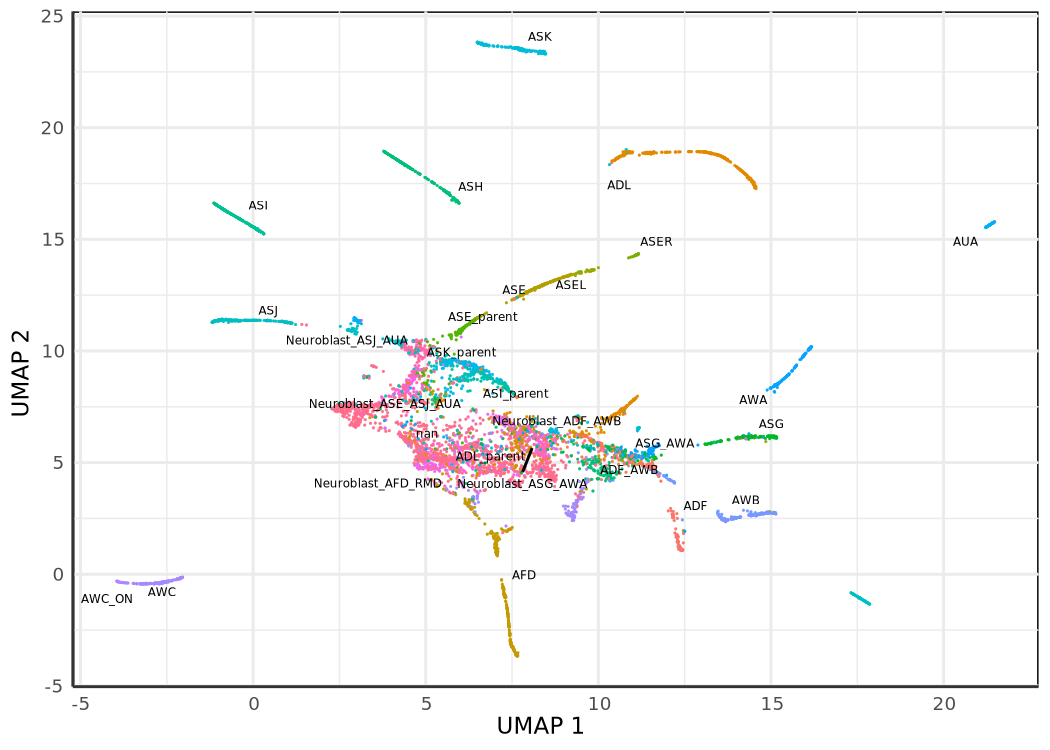

In [6]:
m3.plot_cells(adata, label_groups_by_cluster=False, color_cells_by='cell.type')

## 5. Cluster cells (single partition at this resolution)

/tmp/ipykernel_19449/2759416035.py:2: UserWarning: No trajectory to plot. Has learn_graph() been called yet?
  m3.plot_cells(adata, group_cells_by='partition', color_cells_by='partition')


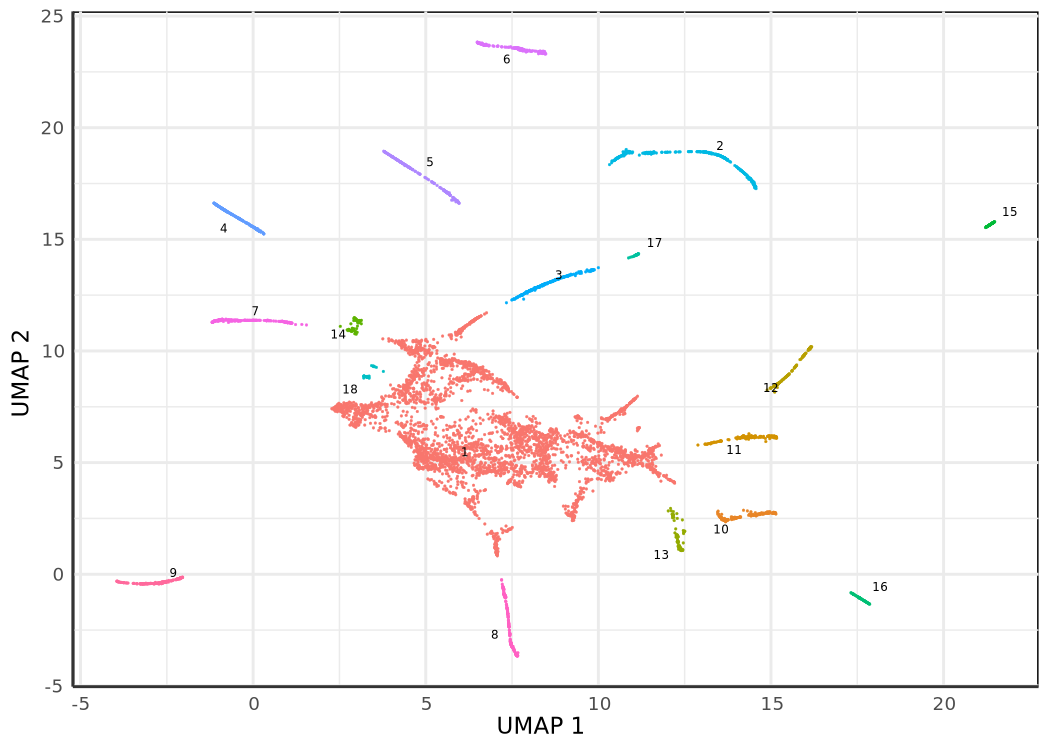

In [7]:
m3.cluster_cells(adata, resolution=5e-6)
m3.plot_cells(adata, group_cells_by='partition', color_cells_by='partition')

## 6. Learn principal graph

The default `ncenter` heuristic produces too coarse a graph for embryo data. Setting `ncenter=1000` matches the R vignette.

In [8]:
m3.learn_graph(adata, learn_graph_control={'ncenter': 1000})

AnnData object with n_obs × n_vars = 6188 × 20222
    obs: 'cell', 'n.umi', 'time.point', 'batch', 'Size_Factor', 'raw.embryo.time', 'embryo.time', 'embryo.time.bin', 'raw.embryo.time.bin', 'lineage', 'num_genes_expressed', 'cell.type', 'bg.300.loading', 'bg.400.loading', 'bg.500.1.loading', 'bg.500.2.loading', 'bg.r17.loading', 'bg.b01.loading', 'bg.b02.loading', 'monocle3_clusters', 'monocle3_partitions'
    var: 'id', 'gene_short_name', 'num_cells_expressed'
    uns: 'monocle3'
    obsm: 'X_pca', 'X_aligned', 'X_umap'

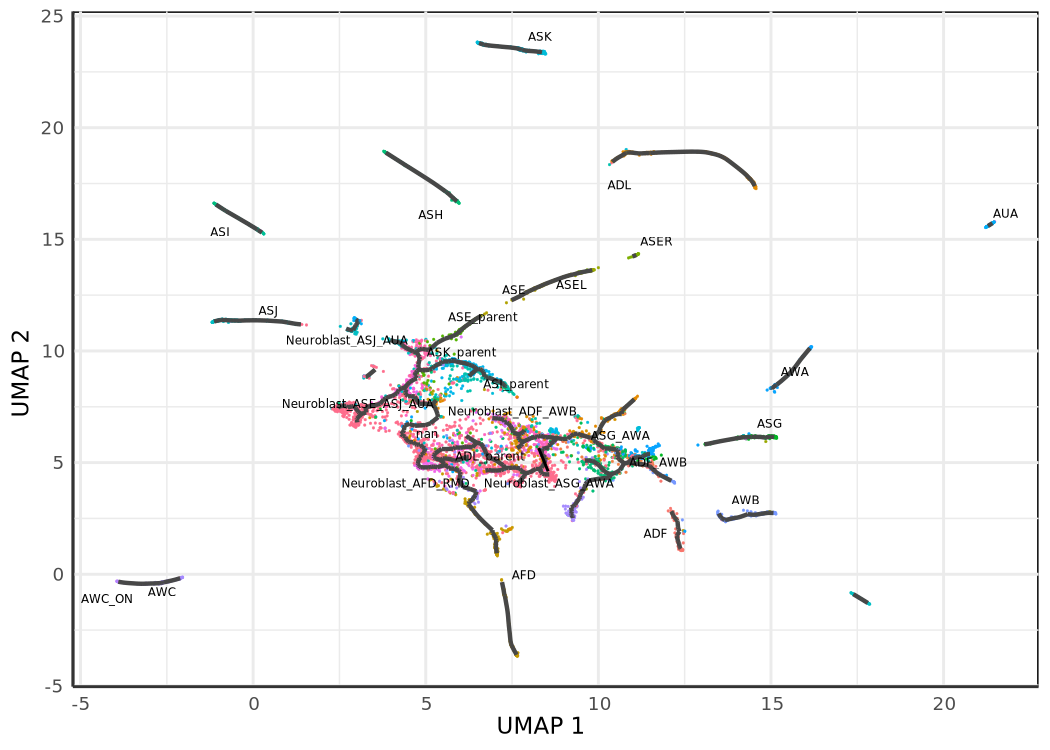

In [9]:
m3.plot_cells(
    adata, color_cells_by='cell.type',
    label_groups_by_cluster=False,
    label_leaves=False, label_branch_points=False,
)

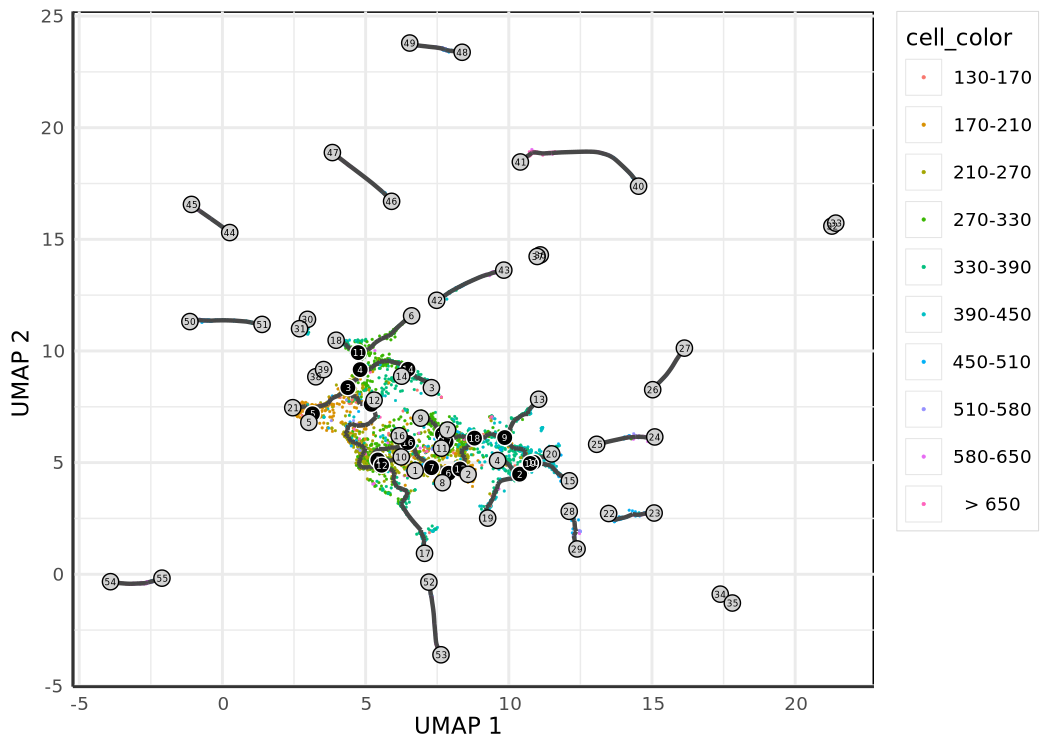

In [10]:
m3.plot_cells(
    adata, color_cells_by='embryo.time.bin',
    label_cell_groups=False,
    label_leaves=True, label_branch_points=True,
    graph_label_size=1.5,
)

## 7. Order cells along pseudotime using a time-bin-aware root

Pseudotime zero is placed at the principal-graph node whose neighbourhood contains the most cells from the earliest time bin (`130-170`).

/scratch/groups/xiaojie/nianping_scratch/Test_ggplot2/ggplot2_py/ggplot2_py/geom.py:531: UserWarning: Removed 2475 rows containing missing values (geom_point).
  return remove_missing(data, vars=check_vars, na_rm=na_rm, name=snake_class(self))


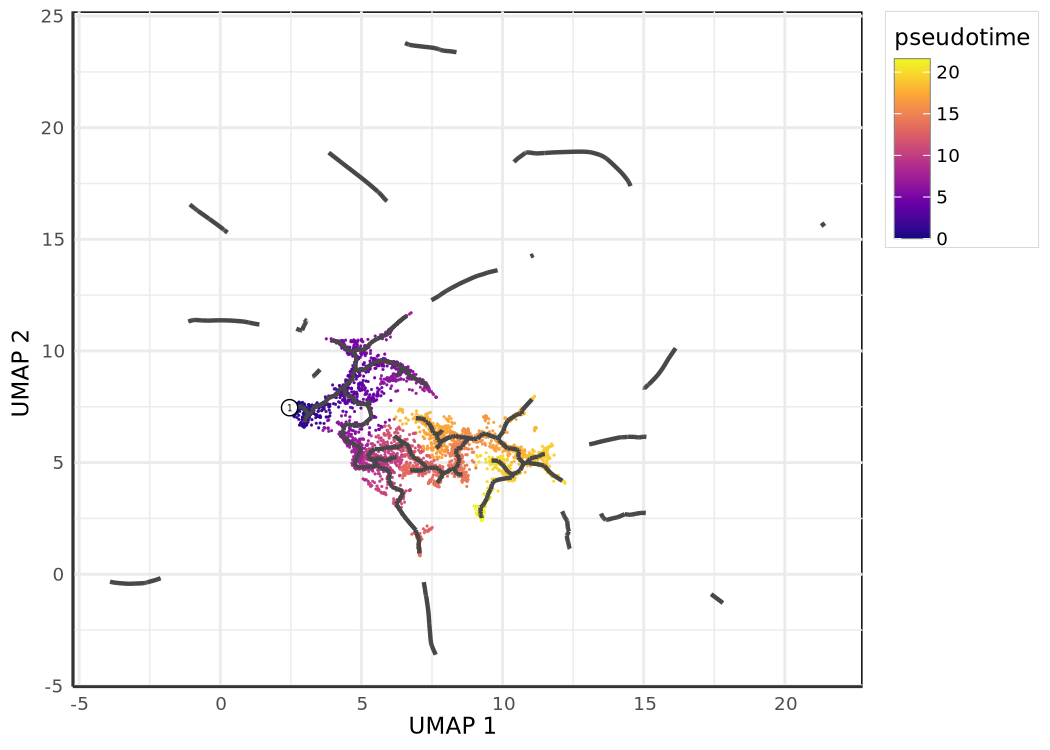

In [11]:
def earliest_principal_node(adata, time_bin='130-170'):
    mask = adata.obs['embryo.time.bin'].astype(str) == time_bin
    closest = adata.uns['monocle3']['principal_graph_aux']['UMAP'][
        'pr_graph_cell_proj_closest_vertex'
    ]['V1'].to_numpy()
    closest_subset = closest[mask.to_numpy()]
    values, counts = np.unique(closest_subset, return_counts=True)
    return [f'Y_{int(values[np.argmax(counts)])}']

m3.order_cells(adata, root_pr_nodes=earliest_principal_node(adata))
m3.plot_cells(
    adata, color_cells_by='pseudotime',
    label_cell_groups=False,
    label_leaves=False, label_branch_points=False,
    graph_label_size=1.5,
)

## 8. Ciliated-neuron marker panel on the trajectory

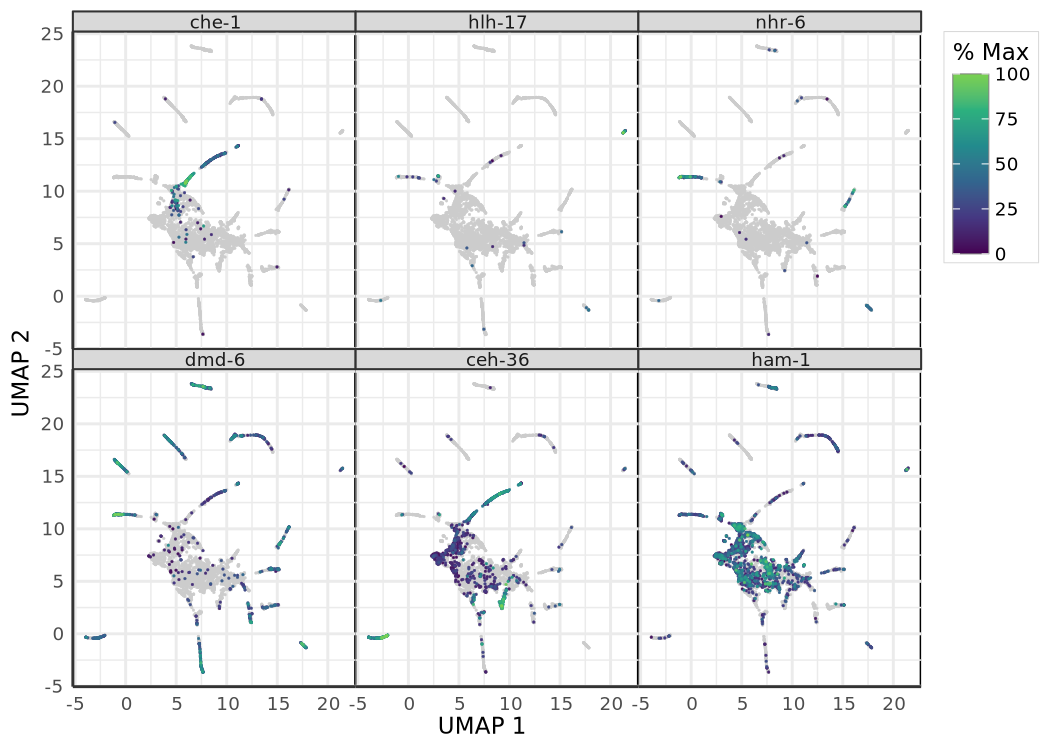

In [12]:
ciliated_genes = ['che-1', 'hlh-17', 'nhr-6', 'dmd-6', 'ceh-36', 'ham-1']

m3.plot_cells(
    adata, genes=ciliated_genes,
    label_cell_groups=False, show_trajectory_graph=False,
)

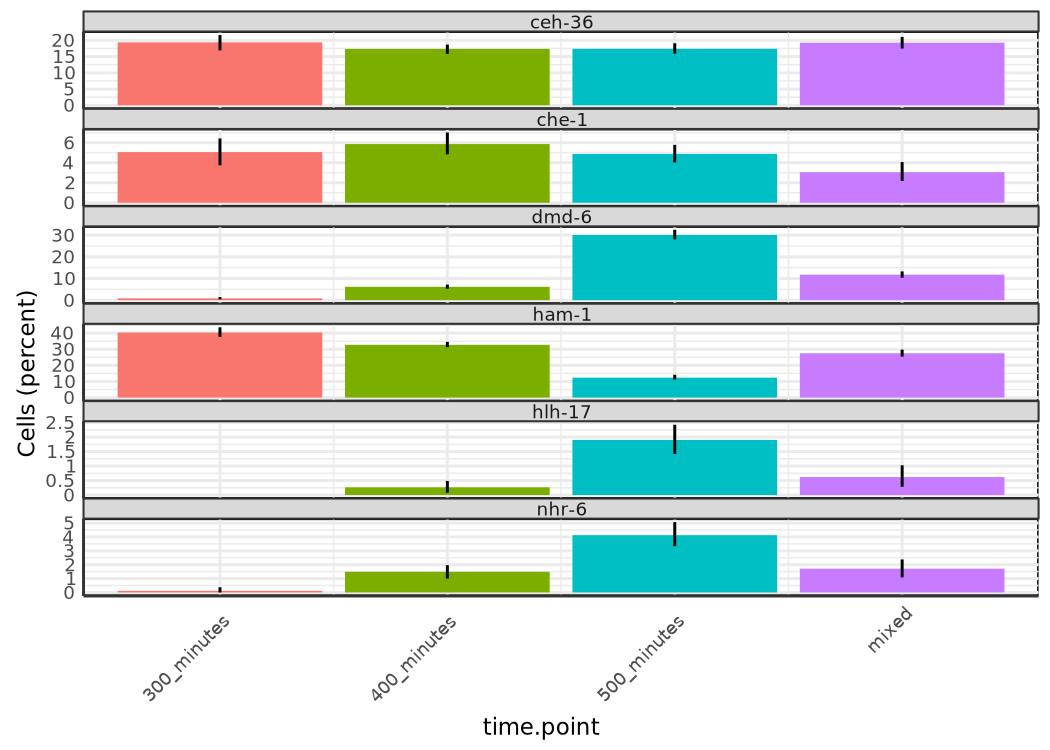

In [13]:
gene_mask = adata.var['gene_short_name'].astype(str).isin(ciliated_genes)
(
    m3.plot_percent_cells_positive(
        adata[:, gene_mask].copy(),
        group_cells_by='time.point',
    )
    + gg.theme(
        axis_text_x=gg.element_text(angle=45, hjust=1),
        legend_position='none',
    )
)

## 9. Differential expression against `embryo.time`

In [14]:
adata.obs['pseudotime'] = m3.pseudotime(adata)
sub = adata[:, gene_mask].copy()

gene_fits_time = m3.fit_models(sub, model_formula_str='~embryo.time')
fit_coefs = m3.coefficient_table(gene_fits_time)

(
    fit_coefs
    .query("term in ('embryo.time', 'embryo_time')")
    .query('q_value < 0.05')
    [['gene_short_name', 'term', 'q_value', 'estimate']]
)

,gene_short_name,term,q_value,estimate
1,ham-1,embryo_time,3.584849e-270,-0.003884
3,dmd-6,embryo_time,0.000000e+00,0.007500
5,hlh-17,embryo_time,7.268970e-06,0.003339
7,nhr-6,embryo_time,8.154372e-43,0.005793
9,ceh-36,embryo_time,4.806073e-207,0.002786
11,che-1,embryo_time,2.523168e-02,-0.000419


/scratch/groups/xiaojie/nianping_scratch/Test_scales/scales_py/scales/transforms.py:488: RuntimeWarning: divide by zero encountered in log
  return np.log(x) / log_base
/scratch/groups/xiaojie/nianping_scratch/Test_ggplot2/ggplot2_py/ggplot2_py/scale.py:709: UserWarning: log-10 transformation introduced infinite values.
  cli_warn(
/scratch/groups/xiaojie/nianping_scratch/Test_ggplot2/ggplot2_py/ggplot2_py/stat.py:2034: UserWarning: Removed 22331 rows containing non-finite values (stat_ydensity).
  data = remove_missing(
/scratch/groups/xiaojie/nianping_scratch/Test_ggplot2/ggplot2_py/ggplot2_py/stat.py:5695: UserWarning: Groups with fewer than two datapoints have been dropped.
  cli_warn("Groups with fewer than two datapoints have been dropped.")
/scratch/groups/xiaojie/nianping_scratch/Test_ggplot2/ggplot2_py/ggplot2_py/stat.py:5695: UserWarning: Groups with fewer than two datapoints have been dropped.
  cli_warn("Groups with fewer than two datapoints have been dropped.")
/scratch/gr

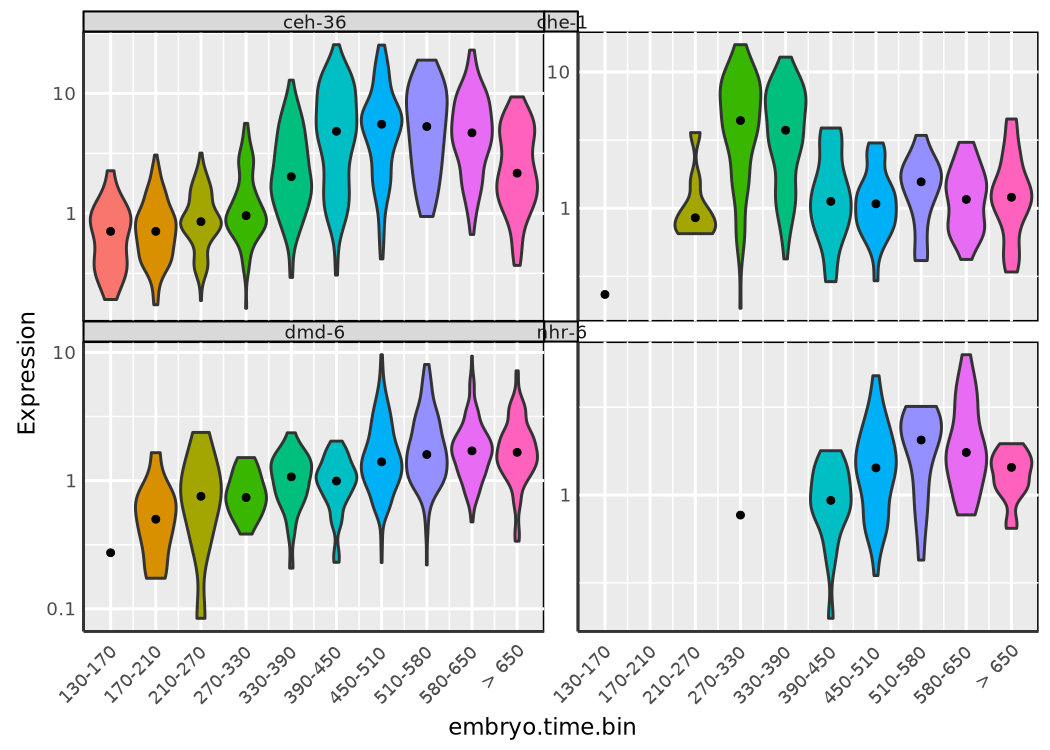

In [15]:
violin_mask = adata.var['gene_short_name'].astype(str).isin(
    ['che-1', 'nhr-6', 'dmd-6', 'ceh-36']
)
(
    m3.plot_genes_violin(
        adata[:, violin_mask].copy(),
        group_cells_by='embryo.time.bin', ncol=2,
    )
    + gg.theme(axis_text_x=gg.element_text(angle=45, hjust=1))
)

## 10. Adding `batch` as a covariate + fit evaluation

In [16]:
gene_fits_batch = m3.fit_models(sub, model_formula_str='~embryo.time + batch')

m3.coefficient_table(gene_fits_batch) \
    .query("term not in ('Intercept', '(Intercept)')") \
    [['gene_short_name', 'term', 'q_value', 'estimate']]

,gene_short_name,term,q_value,estimate
1,ham-1,batchMurray_b02,1.710870e-01,-0.264264
2,ham-1,batchMurray_r17,5.459645e-06,0.279986
3,ham-1,batchWaterston_300_minutes,1.837767e-03,0.186757
4,ham-1,batchWaterston_400_minutes,6.959821e-15,0.398511
5,ham-1,batchWaterston_500_minutes_batch_1,3.569351e-02,-0.169793
6,ham-1,batchWaterston_500_minutes_batch_2,2.311869e-21,-1.212678
7,ham-1,embryo_time,2.161669e-91,-0.002764
9,dmd-6,batchMurray_b02,6.596675e-01,0.157882
10,dmd-6,batchMurray_r17,2.694475e-01,-0.310019
11,dmd-6,batchWaterston_300_minutes,5.489209e-07,-1.957714


In [17]:
m3.evaluate_fits(gene_fits_batch)

,id,gene_id,gene_short_name,num_cells_expressed,status,null_deviance,df_null,logLik,AIC,BIC,deviance,df_residual
0,WBGene00001820,WBGene00001820,ham-1,1618,OK,16356.888905,6187.0,NaN,NaN,NaN,14491.713935,6180.0
1,WBGene00007058,WBGene00007058,dmd-6,873,OK,6766.190611,6187.0,NaN,NaN,NaN,4096.079141,6180.0
2,WBGene00001961,WBGene00001961,hlh-17,51,OK,686.586907,6187.0,NaN,NaN,NaN,599.854112,6180.0
3,WBGene00003605,WBGene00003605,nhr-6,133,OK,1702.881516,6187.0,NaN,NaN,NaN,1437.818386,6180.0
4,WBGene00000457,WBGene00000457,ceh-36,1123,OK,17213.396312,6187.0,NaN,NaN,NaN,15597.121060,6180.0
5,WBGene00000483,WBGene00000483,che-1,292,OK,8304.332528,6187.0,NaN,NaN,NaN,7912.863187,6180.0


## 11. LR test: does `batch` actually help? (negbinomial)

In [18]:
time_models = m3.fit_models(
    sub, model_formula_str='~embryo.time', expression_family='negbinomial'
)
time_batch_models = m3.fit_models(
    sub, model_formula_str='~embryo.time + batch', expression_family='negbinomial'
)

m3.compare_models(time_batch_models, time_models)[['gene_id', 'q_value']]

/home/groups/xiaojie/nianping/Conda_Files/envs/scomics/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/home/groups/xiaojie/nianping/Conda_Files/envs/scomics/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/home/groups/xiaojie/nianping/Conda_Files/envs/scomics/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3663: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/home/groups/xiaojie/nianping/Conda_Files/envs/scomics/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/home/groups/xiaojie/nianping/Conda_Files/envs/scomics/lib/python3.11/site-packages/statsm

,gene_id,q_value
0,WBGene00001820,3.849899e-19
1,WBGene00007058,1.844147e-48
2,WBGene00001961,1.000000e+00
3,WBGene00003605,1.196994e-59
4,WBGene00000457,8.496969e-13
5,WBGene00000483,1.689028e-06


## 12. DE along pseudotime via natural spline

In [19]:
finite = np.isfinite(adata.obs['pseudotime'].to_numpy())
sub_pt = adata[finite][:, gene_mask].copy()

gene_fits_pt = m3.fit_models(
    sub_pt,
    model_formula_str='~splines::ns(pseudotime, df=3)',
)
(
    m3.coefficient_table(gene_fits_pt)
    .loc[lambda d: d['term'].str.contains('pseudotime')]
    .assign(q_value=lambda d: d['q_value'].fillna(1.0))
    .query('q_value < 0.05')
    [['gene_short_name', 'term', 'q_value', 'estimate']]
)

,gene_short_name,term,q_value,estimate
1,ham-1,"cr(pseudotime, df=3)[0]",5.034616e-60,0.420123
3,ham-1,"cr(pseudotime, df=3)[2]",1.709262e-18,-0.368197
5,dmd-6,"cr(pseudotime, df=3)[0]",1.185161e-09,-1.339795
6,dmd-6,"cr(pseudotime, df=3)[1]",1.594450e-08,-1.201559
9,hlh-17,"cr(pseudotime, df=3)[0]",2.738034e-02,-3.835054
14,nhr-6,"cr(pseudotime, df=3)[1]",7.655715e-03,-2.954027
18,ceh-36,"cr(pseudotime, df=3)[1]",5.243629e-284,-1.852880
19,ceh-36,"cr(pseudotime, df=3)[2]",4.330275e-272,1.470205
21,che-1,"cr(pseudotime, df=3)[0]",4.380807e-54,7.306363
22,che-1,"cr(pseudotime, df=3)[1]",4.001439e-87,8.627712


## 13. Principal-graph-wide DE — Moran's I + gene modules

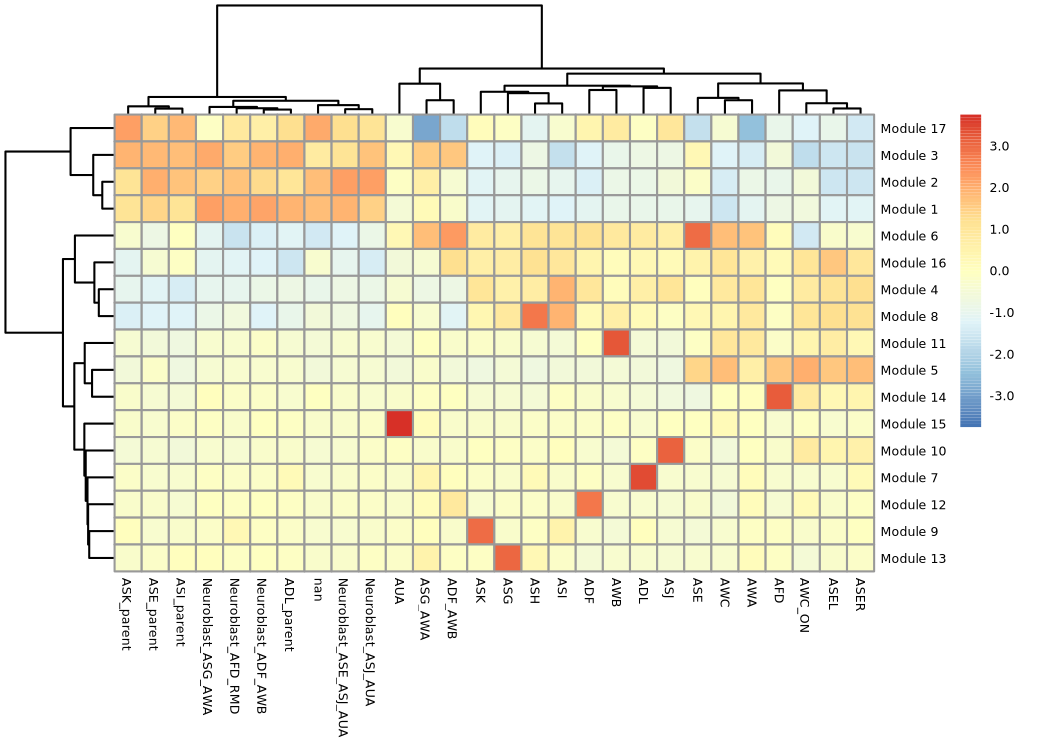

In [20]:
pr_graph_test_res = m3.graph_test(adata, neighbor_graph='principal_graph', cores=4)
pr_deg_ids = pr_graph_test_res.query('q_value < 0.05').index.tolist()

gene_module_df = m3.find_gene_modules(adata[:, pr_deg_ids].copy(), resolution=1e-3)
cell_group_df = pd.DataFrame({
    'cell': adata.obs_names,
    'cell_group': adata.obs['cell.type'].astype(str).to_numpy(),
})

agg_mat = m3.aggregate_gene_expression(
    adata,
    gene_group_df=gene_module_df[['id', 'module']],
    cell_group_df=cell_group_df,
)
agg_mat.index = ['Module ' + str(i) for i in agg_mat.index]

import pheatmap
pheatmap.pheatmap(
    agg_mat, scale='column', clustering_method='ward.D2', fontsize=6,
)

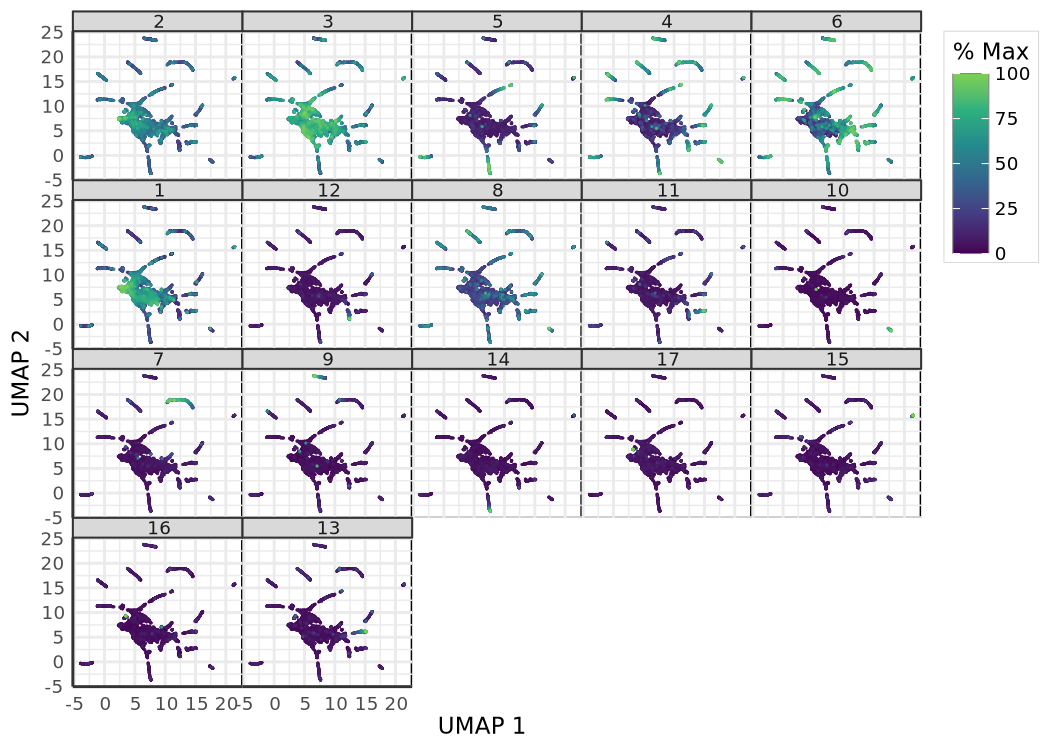

In [21]:
m3.plot_cells(adata, genes=gene_module_df, label_cell_groups=False, show_trajectory_graph=False)

## 14. AFD-lineage gene dynamics along pseudotime

The upstream tutorial hard-codes cluster IDs 22 / 28 / 35 for the AFD lineage. Our clustering won't match those IDs, so we pick the three most populous clusters.

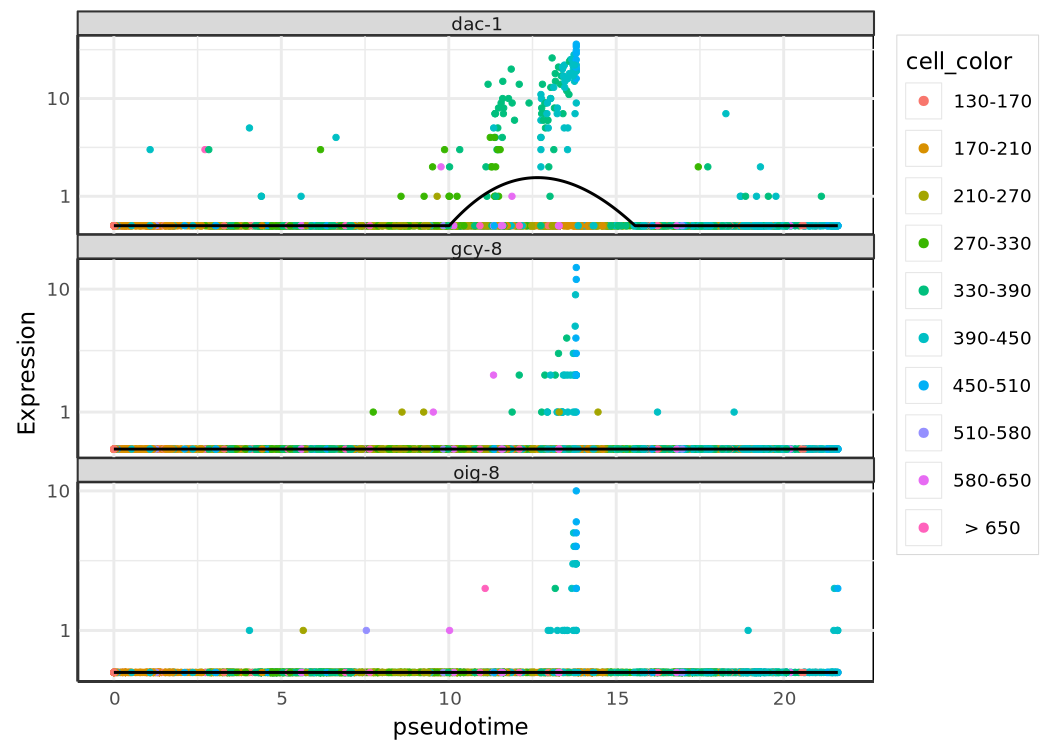

In [22]:
cluster_counts = m3.clusters(adata).value_counts()
top_clusters = cluster_counts.head(3).index.tolist()
afd_mask = m3.clusters(adata).isin(top_clusters)

afd_cds = adata[afd_mask.to_numpy()].copy()
afd_genes_mask = afd_cds.var['gene_short_name'].astype(str).isin(
    ['gcy-8', 'dac-1', 'oig-8']
)

m3.plot_genes_in_pseudotime(
    afd_cds[:, afd_genes_mask].copy(),
    color_cells_by='embryo.time.bin',
    min_expr=0.5,
)

## 15. 3D trajectory (re-embed with `max_components = 3`)

`plot_cells_3d` is the only site where `plotly.py` is imported in the whole port.

In [23]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [24]:
# Re-embed in 3D using the already-processed adata (matches the R vignette,
# which calls ``reduce_dimension(cds, max_components=3)`` on the 2D-pipeline
# cds rather than rebuilding from scratch).
cds_3d = adata.copy()
m3.reduce_dimension(cds_3d, max_components=3)
m3.cluster_cells(cds_3d)
m3.learn_graph(cds_3d)
m3.order_cells(cds_3d, root_pr_nodes=earliest_principal_node(cds_3d))

/tmp/ipykernel_19449/2157111273.py:5: UserWarning: No preprocess_method specified, and aligned coordinates have been computed previously. Using preprocess_method = 'Aligned'
  m3.reduce_dimension(cds_3d, max_components=3)


AnnData object with n_obs × n_vars = 6188 × 20222
    obs: 'cell', 'n.umi', 'time.point', 'batch', 'Size_Factor', 'raw.embryo.time', 'embryo.time', 'embryo.time.bin', 'raw.embryo.time.bin', 'lineage', 'num_genes_expressed', 'cell.type', 'bg.300.loading', 'bg.400.loading', 'bg.500.1.loading', 'bg.500.2.loading', 'bg.r17.loading', 'bg.b01.loading', 'bg.b02.loading', 'monocle3_clusters', 'monocle3_partitions', 'monocle3_pseudotime', 'pseudotime'
    var: 'id', 'gene_short_name', 'num_cells_expressed'
    uns: 'monocle3'
    obsm: 'X_pca', 'X_aligned', 'X_umap'

In [25]:
m3.plot_cells_3d(cds_3d, color_cells_by='partition', cell_size=10)